# Обработка фото рисунка

In [12]:
%load_ext autoreload
%autoreload 2

import json
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image
from utils import (
    detect_and_align, alignment_error, extract_colored,
    transfer_color, template_meta,
    build_triangulation, animate_character, overlay_character
)

# --- конфиг персонажа ---
CHAR_ID = "001"
CHAR_DIR = f"templates/{CHAR_ID}"

TEMPLATE_IMG_PATH = f"{CHAR_DIR}/img.png"
TEMPLATE_MASK_PATH = f"{CHAR_DIR}/mask.png"
TEMPLATE_SKELETON_PATH = f"{CHAR_DIR}/skeleton.json"
MOTION_PATH = f"{CHAR_DIR}/motion.json"

# --- конфиг фото ---
PHOTO_PATH = f"input/{CHAR_ID}_photo_v2.jpg"
CONTENT_SCALE = 0.8

CANVAS_SIZE = (1240, 1754)
MARKER_PX = 80
MARGIN = 60
CONTENT_PAD = 10

meta = template_meta(CANVAS_SIZE, MARKER_PX, MARGIN, CONTENT_PAD)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Шаг 1. Выравнивание по ArUco

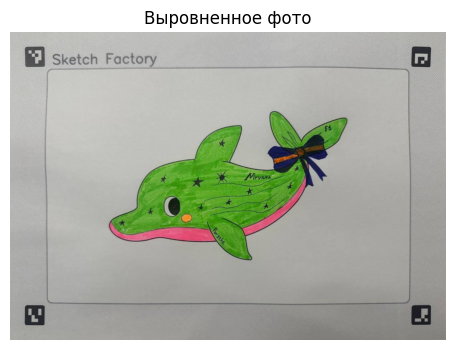

In [13]:
result = detect_and_align(PHOTO_PATH, meta)
aligned = result["aligned"]

plt.figure(figsize=(7, 4))
plt.imshow(cv2.cvtColor(aligned, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("Выровненное фото")
plt.show()

In [3]:
mean_err, errors = alignment_error(aligned, meta)
print(f"Средняя ошибка: {mean_err:.2f} px")
if mean_err < 1:
    print("Отлично!")
elif mean_err < 3:
    print("Нормально")
else:
    print("Плохо — лучше переснять")


Средняя ошибка: 3.88 px
Плохо — лучше переснять


## Шаг 3. Вырезка рисунка


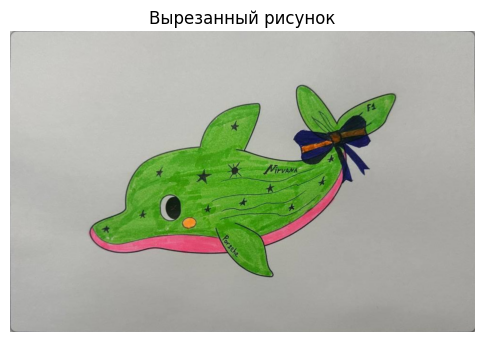

In [4]:
extracted = extract_colored(aligned, meta)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(extracted["rgba"], cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title("Вырезанный рисунок")
plt.show()

## Шаг 4. Перенос цвета на оригинал

### Логика 3

In [ ]:
# Вычисляем, где именно на шаблоне должен быть персонаж (image_rect)
ov = overlay_character(
    template_path=f"templates/{CHAR_ID}/template.png", # путь к чистому шаблону
    img_path=TEMPLATE_IMG_PATH,
    content_scale=0.8, # такой же, как при создании шаблона
    canvas_size=CANVAS_SIZE,
    marker_px=MARKER_PX,
    margin=MARGIN,
    content_pad=CONTENT_PAD,
)
image_rect = ov["image_rect"]
print(f"Координаты персонажа найдены: {image_rect}")

Координаты персонажа найдены: [345, 244, 1064, 752]


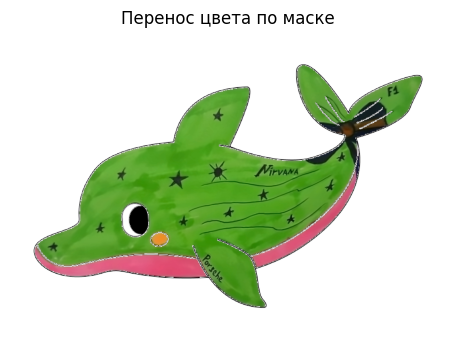

In [7]:
colored = transfer_color(aligned, TEMPLATE_IMG_PATH, TEMPLATE_MASK_PATH, image_rect)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(colored["rgba"], cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title("Перенос цвета по маске")
plt.show()

### [old]

#### [old] логика2

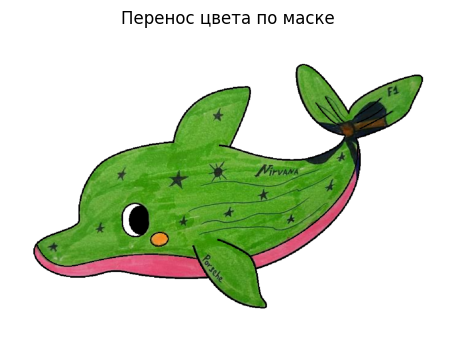

In [ ]:
# image_rect (на случай если ячейка шага 4 не запускалась)
original = cv2.imread(TEMPLATE_IMG_PATH, cv2.IMREAD_UNCHANGED)
oh, ow = original.shape[:2]
bx, by, bw, bh = meta["drawing_bbox"]
scale = min(bw / ow, bh / oh) * CONTENT_SCALE
iw, ih = int(ow * scale), int(oh * scale)
ix = bx + (bw - iw) // 2
iy = by + (bh - ih) // 2

# маска
mask = cv2.imread(TEMPLATE_MASK_PATH, cv2.IMREAD_GRAYSCALE)
mask = cv2.resize(mask, (iw, ih), interpolation=cv2.INTER_NEAREST)

contour = mask < 50
fill = mask > 200
between = ~contour & ~fill  # промежуточные значения

photo_crop = aligned[iy : iy + ih, ix : ix + iw]

result = np.zeros((ih, iw, 4), dtype=np.uint8)
result[contour] = [0, 0, 0, 255]           # чёрные контуры
result[fill, :3] = photo_crop[fill]         # цвет с фото
result[fill, 3] = 255
result[between] = [255, 255, 255, 255]      # промежуточное → белый

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title("Перенос цвета по маске")
plt.show()

#### [old] логика1

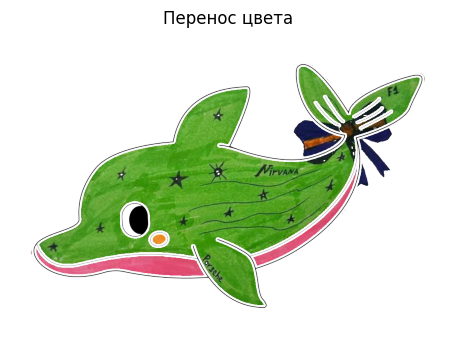

In [ ]:
# пересчитываем image_rect (та же логика что в overlay_character)
original = cv2.imread(TEMPLATE_IMG_PATH, cv2.IMREAD_UNCHANGED)
ih, iw = original.shape[:2]
bx, by, bw, bh = meta["drawing_bbox"]
scale = min(bw / iw, bh / ih) * CONTENT_SCALE
tw, th = int(iw * scale), int(ih * scale)
x0 = bx + (bw - tw) // 2
y0 = by + (bh - th) // 2
image_rect = [x0, y0, tw, th]

colored = transfer_color(aligned, TEMPLATE_IMG_PATH, image_rect)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(colored["rgba"], cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title("Перенос цвета")
plt.show()

In [ ]:
import cv2
import numpy as np

mask = cv2.imread(TEMPLATE_MASK_PATH, cv2.IMREAD_GRAYSCALE)
unique, counts = np.unique(mask, return_counts=True)

print(f"Размер маски: {mask.shape}")
print(f"\nУникальных значений: {len(unique)}")
print(f"{'Значение':>10} {'Пикселей':>10} {'Доля %':>8}")
print("-" * 30)
for v, c in zip(unique, counts):
    print(f"{v:>10} {c:>10} {c / mask.size * 100:>7.1f}%")


Размер маски: (595, 842)

Уникальных значений: 3
  Значение   Пикселей   Доля %
------------------------------
         0      12346     2.5%
       128     342801    68.4%
       255     145843    29.1%


### Пробуем сохранить примыкающие объекты

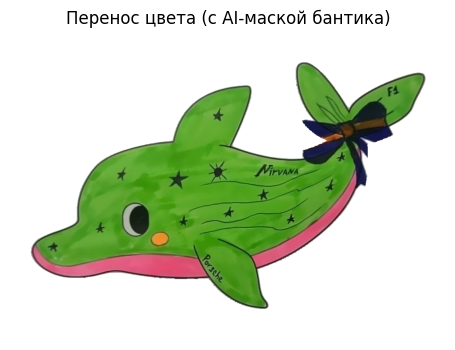

In [35]:
# если rembg еще не стоит:
# !pip install rembg onnxruntime

import cv2
import numpy as np
from rembg import remove

# photo_crop уже есть в твоем ноутбуке (вырезка aligned[iy:iy+ih, ix:ix+iw])
# mask уже есть (resize до iw, ih)

# 1) AI-удаление фона -> alpha маска объекта (кит + бантик)
ok, buf = cv2.imencode(".png", photo_crop)
fg_png = remove(buf.tobytes())  # bytes PNG RGBA
fg = cv2.imdecode(np.frombuffer(fg_png, np.uint8), cv2.IMREAD_UNCHANGED)
fg_alpha = fg[:, :, 3] > 32

# 2) Чистим мелкий мусор
k3 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
fg_alpha = cv2.morphologyEx(fg_alpha.astype(np.uint8), cv2.MORPH_OPEN, k3, iterations=1).astype(bool)

# 3) Твоя шаблонная маска кита
contour = mask < 50
fill_core = mask > 200

# 4) "Экстра" часть (бантик) = foreground вне шаблона, но рядом с китом
near = cv2.dilate((contour | fill_core).astype(np.uint8), np.ones((35, 35), np.uint8), iterations=1).astype(bool)
fill_extra = fg_alpha & (~fill_core) & near

# 5) Финальная заливка
fill = fill_core | fill_extra
between = (~contour) & (~fill)

# 6) (опционально) твой антишум цвета
clean = cv2.fastNlMeansDenoisingColored(photo_crop, None, 8, 8, 7, 21)
lab = cv2.cvtColor(clean, cv2.COLOR_BGR2LAB)
L, A, B = cv2.split(lab)
A = cv2.GaussianBlur(A, (0, 0), 3.0)
B = cv2.GaussianBlur(B, (0, 0), 3.0)
flat = cv2.cvtColor(cv2.merge([L, A, B]), cv2.COLOR_LAB2BGR)

# 7) Сборка результата
result = np.zeros((ih, iw, 4), dtype=np.uint8)
result[between] = [255, 255, 255, 255]      # фон
result[contour] = [0, 0, 0, 255]            # контур
result[fill, :3] = flat[fill]               # цвет
result[fill, 3] = 255

# если хочешь, чтобы бантик был "поверх" линий:
result[fill_extra, :3] = flat[fill_extra]
result[fill_extra, 3] = 255

plt.figure(figsize=(6,4))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGRA2RGBA))
plt.title("Перенос цвета (с AI-маской бантика)")
plt.axis("off")
plt.show()


## Шаг 5. Скелет + триангуляция

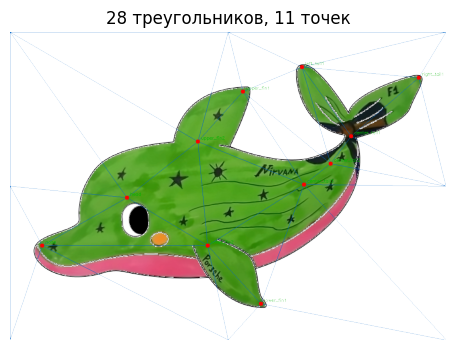

In [8]:
with open(TEMPLATE_SKELETON_PATH, encoding="utf-8") as f:
    keypoints = json.load(f)["keypoints"]

th, tw = colored["rgba"].shape[:2]
ctrl_pts, tri, n_kp, names = build_triangulation(keypoints, tw, th)
skel_pts = ctrl_pts[:n_kp]

# визуализация
vis = colored["rgba"].copy()
for simplex in tri.simplices:
    pts = ctrl_pts[simplex].astype(np.int32)
    cv2.polylines(vis, [pts], True, (200, 100, 0, 255), 1)
for pt, name in zip(skel_pts, names):
    x, y = pt.astype(int)
    cv2.circle(vis, (x, y), 5, (0, 0, 255, 255), -1)
    cv2.putText(vis, name, (x + 8, y - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.35, (0, 180, 0, 255), 1)

plt.figure(figsize=(6, 4))
plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGRA2RGBA))
plt.axis("off")
plt.title(f"{len(tri.simplices)} треугольников, {n_kp} точек")
plt.show()

## Шаг 6. Анимация

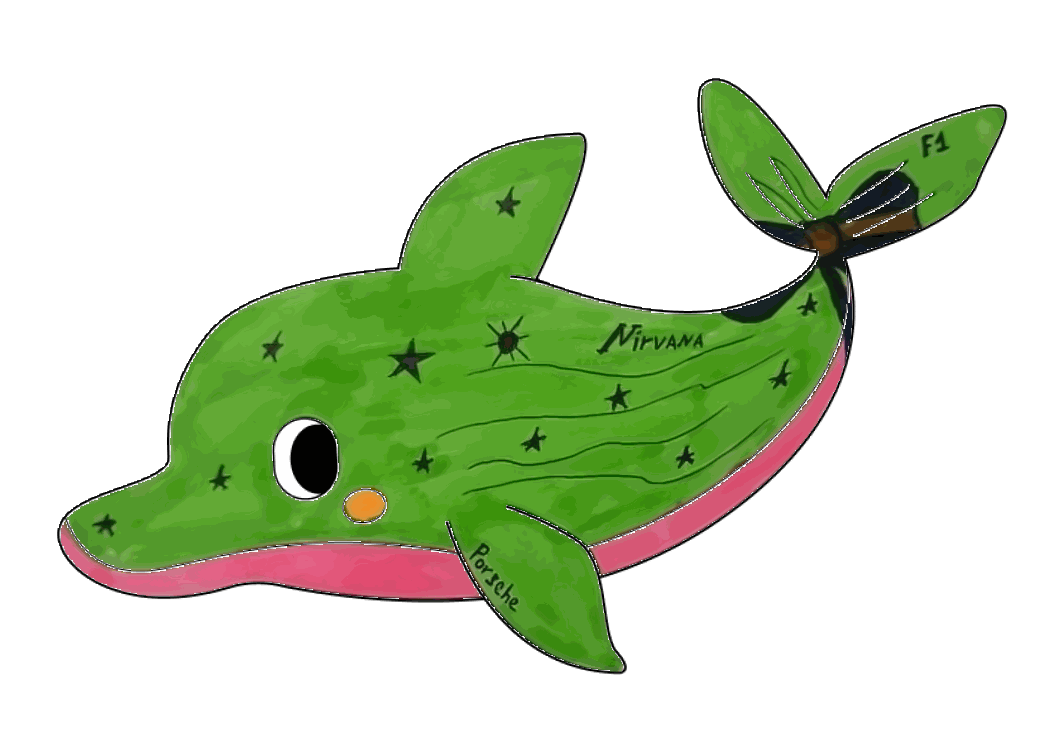

In [9]:
from IPython.display import Image as IPImage, display

# загружаем motion config
with open(MOTION_PATH, encoding="utf-8") as f:
    motion_cfg = json.load(f)

# анимируем (colored["rgba"] из предыдущей ячейки)
frames = animate_character(colored["rgba"], keypoints, motion_cfg)

# сохраняем GIF
pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGRA2RGBA)) for f in frames]
gif_path = f"output/{CHAR_ID}_anim.gif"
pil_frames[0].save(gif_path, save_all=True, append_images=pil_frames[1:],
                   duration=1000 // 15, loop=0, disposal=2)
display(IPImage(filename=gif_path, width=500))